In [1]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import os

In [2]:
file_path = "CPI20.xlsx"
cpi = pd.read_excel(file_path, index_col=0)

In [4]:
cpi.index = pd.to_datetime(cpi.index, format='%Y-%m')
cpi = cpi.asfreq('MS')
cpi.head()

,CPI
Date,
2005-01-01,191.6
2005-02-01,192.4
2005-03-01,193.1
2005-04-01,193.7
2005-05-01,193.6


In [5]:
# Resample CPI to annual frequency by taking the mean for each year
annual_cpi = cpi.resample('Y').mean()

# Calculate annual inflation rate as percentage change from previous year
annual_inflation = annual_cpi.pct_change() * 100

# Rename columns for clarity
annual_cpi.columns = ['Annual_CPI']
annual_inflation.columns = ['Annual_Inflation']

# Display results
print(annual_cpi)
print(annual_inflation)

            Annual_CPI
Date                  
2005-12-31  195.266667
2006-12-31  201.558333
2007-12-31  207.344167
2008-12-31  215.254250
2009-12-31  214.564667
2010-12-31  218.076167
2011-12-31  224.923000
2012-12-31  229.586083
2013-12-31  232.951750
2014-12-31  236.715000
2015-12-31  237.001750
2016-12-31  240.005417
2017-12-31  245.121000
2018-12-31  251.099500
2019-12-31  255.652583
2020-12-31  258.855750
2021-12-31  270.967917
2022-12-31  292.625417
2023-12-31  304.704167
2024-12-31  313.697833
2025-12-31  320.796625
            Annual_Inflation
Date                        
2005-12-31               NaN
2006-12-31          3.222089
2007-12-31          2.870550
2008-12-31          3.814953
2009-12-31         -0.320358
2010-12-31          1.636570
2011-12-31          3.139652
2012-12-31          2.073191
2013-12-31          1.465972
2014-12-31          1.615463
2015-12-31          0.121137
2016-12-31          1.267361
2017-12-31          2.131445
2018-12-31          2.439000
2019-12

/var/folders/b4/37mclspn5hb08s778j8dsmpw0000gn/T/ipykernel_79944/1504946239.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_cpi = cpi.resample('Y').mean()


In [6]:
annual_cpi.index = annual_cpi.index.year
annual_inflation.index = annual_inflation.index.year

In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings
import numpy as np

In [8]:
cpi_series = cpi['CPI']
cpi_series = cpi_series.loc[cpi_series.index >= '2005-01-01']

# --- Split into train/validation (last 24 months for validation)
train = cpi_series[:-24]
valid = cpi_series[-24:]

# --- SARIMA parameter grid search (with seasonality)
warnings.filterwarnings("ignore")
best_order = None
best_seasonal_order = None
best_rmse = float('inf')
best_model = None

p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1, 2]
P_values = [0, 1]
D_values = [0, 1]
Q_values = [0, 1]

orders = list(itertools.product(p_values, d_values, q_values))
seasonal_orders = list(itertools.product(P_values, D_values, Q_values, [12]))

for order in orders:
    for seasonal_order in seasonal_orders:
        try:
            model = SARIMAX(train,
                            order=order,
                            seasonal_order=seasonal_order,
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            results = model.fit(disp=False)
            pred = results.forecast(steps=len(valid))
            rmse = np.sqrt(np.mean((valid.values - pred.values) ** 2))
            if rmse < best_rmse:
                best_rmse = rmse
                best_order = order
                best_seasonal_order = seasonal_order
                best_model = results
        except:
            continue

print("Best SARIMA order:", best_order)
print("Best SARIMA seasonal order:", best_seasonal_order)
print("Best RMSE value:", round(best_rmse, 3))
print("\nBest model parameters:\n", best_model.params)


Best SARIMA order: (1, 0, 1)
Best SARIMA seasonal order: (1, 0, 0, 12)
Best RMSE value: 0.507

Best model parameters:
 ar.L1       1.002204
ma.L1       0.543612
ar.S.L12   -0.059087
sigma2      0.441450
dtype: float64


In [9]:
print("\nValidation actual vs predicted:")
print(pd.DataFrame({'Actual': valid, 'Predicted': pred}))


Validation actual vs predicted:
             Actual   Predicted
2023-09-01  307.374  307.411996
2023-10-01  307.653  308.223625
2023-11-01  308.087  308.940115
2023-12-01  308.735  309.806761
2024-01-01  309.794  310.561693
2024-02-01  311.022  311.510002
2024-03-01  312.107  312.462037
2024-04-01  313.016  313.175050
2024-05-01  313.140  314.133308
2024-06-01  313.131  315.398707
2024-07-01  313.566  316.156131
2024-08-01  314.131  316.818106
2024-09-01  314.851  317.541723
2024-10-01  315.564  318.280667
2024-11-01  316.449  318.831088
2024-12-01  317.603  319.406494
2025-01-01  319.086  320.169251
2025-02-01  319.775  320.989951
2025-03-01  319.615  321.672298
2025-04-01  320.321  322.348009
2025-05-01  320.580  323.100605
2025-06-01  321.500  324.169995
2025-07-01  322.132  324.779719
2025-08-01  323.364  325.492615


In [10]:
# --- Fit best model on full data and forecast next 24 months
final_model = SARIMAX(cpi_series,
                      order=best_order,
                      seasonal_order=best_seasonal_order,
                      enforce_stationarity=False,
                      enforce_invertibility=False)
final_results = final_model.fit(disp=False)
forecast_cpi = final_results.forecast(steps=24)

# --- Prepare forecasted CPI DataFrame
forecast_cpi_df = pd.DataFrame({'CPI': forecast_cpi})
forecast_cpi_df.index.name = 'Date'

# --- Combine historical + forecast CPI for later annual aggregation
all_cpi = pd.concat([cpi, forecast_cpi_df])
print("\n✅ Forecasted monthly CPI added up to:", all_cpi.index[-1])


✅ Forecasted monthly CPI added up to: 2027-08-01 00:00:00


In [11]:
# Compute monthly inflation (%)
all_cpi['Monthly_Inflation'] = all_cpi['CPI'].pct_change() * 100

In [12]:
# Resample CPI to annual (mean of 12 months)
annual_cpi = all_cpi['CPI'].resample('Y').mean()

# Compute annual inflation (% change year-over-year)
annual_inflation = annual_cpi.pct_change() * 100

# Combine into one DataFrame
annual_cpi_df = pd.DataFrame({
    'Annual_CPI': annual_cpi,
    'Annual_Inflation': annual_inflation
})

# Adjust index to show just the year
annual_cpi_df.index = annual_cpi_df.index.year

print("\n✅ Annual CPI & Inflation (2005–2027):")
print(annual_cpi_df.tail(10))


✅ Annual CPI & Inflation (2005–2027):
      Annual_CPI  Annual_Inflation
Date                              
2018  251.099500          2.439000
2019  255.652583          1.813259
2020  258.855750          1.252937
2021  270.967917          4.679118
2022  292.625417          7.992644
2023  304.704167          4.127717
2024  313.697833          2.951606
2025  322.375018          2.766097
2026  331.320843          2.774975
2027  338.710625          2.230401


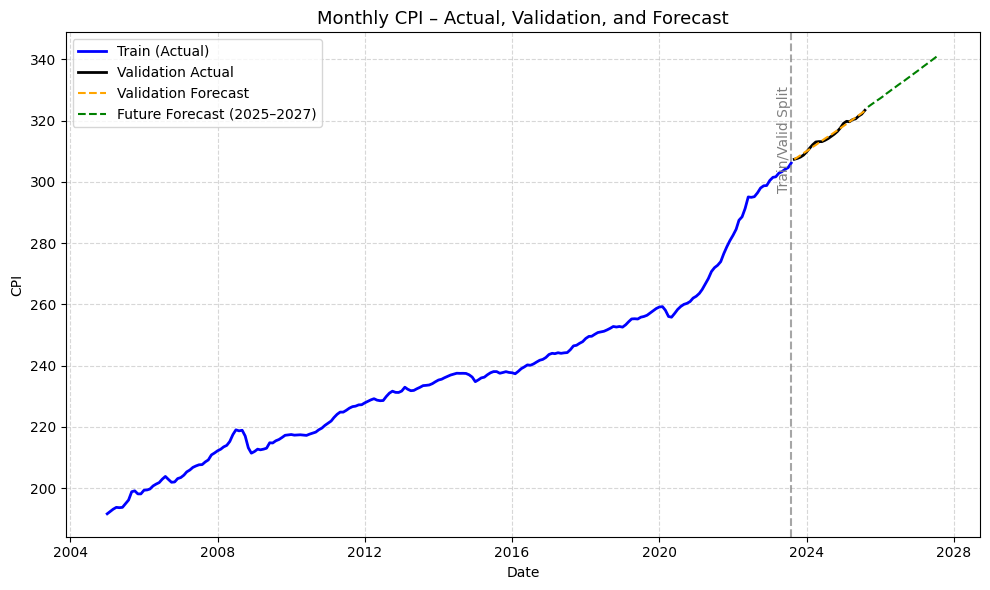

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Actual (train)
plt.plot(train.index, train, color='blue', label='Train (Actual)', linewidth=2)

# Validation (predicted)
pred_valid = best_model.forecast(steps=len(valid))
plt.plot(valid.index, valid, color='black', label='Validation Actual', linewidth=2)
plt.plot(valid.index, pred_valid, color='orange', linestyle='--', label='Validation Forecast')

# Future forecast (2025–2027)
plt.plot(forecast_cpi_df.index, forecast_cpi_df['CPI'], color='green', linestyle='--', label='Future Forecast (2025–2027)')

# Mark split line
plt.axvline(x=train.index[-1], color='gray', linestyle='--', alpha=0.7)
plt.text(train.index[-1], plt.ylim()[1]*0.95, 'Train/Valid Split', rotation=90, va='top', ha='right', color='gray')

plt.title('Monthly CPI – Actual, Validation, and Forecast', fontsize=13)
plt.xlabel('Date')
plt.ylabel('CPI')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

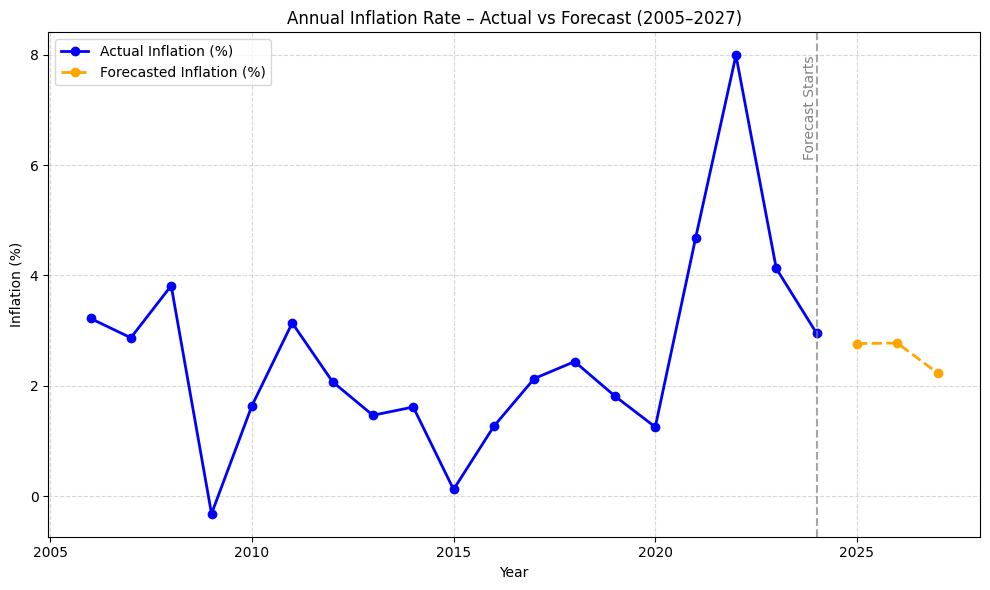

In [14]:
plt.figure(figsize=(10,6))

# Split actual vs forecast
actual_infl = annual_cpi_df.loc[annual_cpi_df.index <= 2024, 'Annual_Inflation']
forecast_infl = annual_cpi_df.loc[annual_cpi_df.index > 2024, 'Annual_Inflation']

# Plot actual
plt.plot(actual_infl.index, actual_infl, color='blue', marker='o', linewidth=2, label='Actual Inflation (%)')

# Plot forecast
plt.plot(forecast_infl.index, forecast_infl, color='orange', marker='o', linestyle='--', linewidth=2, label='Forecasted Inflation (%)')

# Split marker
plt.axvline(x=2024, color='gray', linestyle='--', alpha=0.7)
plt.text(2024, plt.ylim()[1]*0.95, 'Forecast Starts', rotation=90, va='top', ha='right', color='gray')

plt.title('Annual Inflation Rate – Actual vs Forecast (2005–2027)')
plt.xlabel('Year')
plt.ylabel('Inflation (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [15]:
file_path = "Combined_Income.xlsx"

In [16]:
Combined_Income = pd.read_excel(file_path, index_col=0)
Combined_Income.index = pd.to_datetime(Combined_Income.index, format='%Y')
Combined_Income = Combined_Income.asfreq('YS')
Combined_Income.index = Combined_Income.index.year

In [17]:
Combined_Income.head()

,Atlanta,Chicago,Dallas,Houston,Minneapolis,Phoenix,US
Year,,,,,,,
2010,57550,60574,56349,55207,65181,54700,51914
2011,57783,61257,57658,56876,66157,54732,52762
2012,57470,61367,58190,57426,66751,54022,53046
2013,56605,61156,58356,57712,66940,53228,53046
2014,56618,61497,59175,58689,68019,53310,53482


In [18]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

# === 1. Prepare data ===
us_income = Combined_Income['US']
us_income.index = pd.to_datetime(us_income.index, format='%Y')
exog_infl = annual_cpi_df['Annual_Inflation'].loc[us_income.index.year]

# Train–validation split (last 3 years for validation)
train_y, valid_y = us_income.iloc[:-3], us_income.iloc[-3:]
train_exog, valid_exog = exog_infl.iloc[:-3], exog_infl.iloc[-3:]

# === 2. Minimal, robust grid ===
param_grid = [(0,1,1), (1,1,1)]

best_rmse, best_order, best_model = np.inf, None, None

for order in param_grid:
    try:
        model = SARIMAX(train_y, exog=train_exog,
                        order=order, seasonal_order=(0,0,0,0),
                        enforce_stationarity=False, enforce_invertibility=False)
        results = model.fit(disp=False)
        pred = results.forecast(steps=len(valid_y), exog=valid_exog)
        rmse = np.sqrt(np.mean((valid_y.values - pred.values)**2))
        if rmse < best_rmse:
            best_rmse, best_order, best_model = rmse, order, results
    except:
        continue

# === 3. Fallback to ARIMA if SARIMAX fails ===
if best_model is None:
    print("⚠️ SARIMAX failed to converge — using ARIMA(1,1,1) as fallback.")
    model = SARIMAX(train_y, order=(1,1,1), seasonal_order=(0,0,0,0),
                    enforce_stationarity=False, enforce_invertibility=False)
    best_model = model.fit(disp=False)
    best_order = (1,1,1)
    best_rmse = np.nan  # no exog validation

print(f"✅ Best order: {best_order}")
print(f"Validation RMSE: {best_rmse if not np.isnan(best_rmse) else 'N/A'}")
print("\nModel parameters:")
print(best_model.params)

⚠️ SARIMAX failed to converge — using ARIMA(1,1,1) as fallback.
✅ Best order: (1, 1, 1)
Validation RMSE: N/A

Model parameters:
ar.L1          1.194940
ma.L1         -0.038276
sigma2    543692.338339
dtype: float64


In [19]:
# Manually evaluate ARIMA performance (train until 2021, validate 2022–2024)
train_y = us_income.iloc[:-3]
valid_y = us_income.iloc[-3:]

model_arima = SARIMAX(train_y,
                      order=(1,1,1),
                      seasonal_order=(0,0,0,0),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
fit_arima = model_arima.fit(disp=False)

# Forecast for validation period
pred_valid = fit_arima.forecast(steps=len(valid_y))
rmse_arima = np.sqrt(np.mean((valid_y.values - pred_valid.values) ** 2))

print(f"Manual Validation RMSE for ARIMA(1,1,1): {rmse_arima:.2f}")

Manual Validation RMSE for ARIMA(1,1,1): 2851.04


In [20]:
# === 1. Refit ARIMA(1,1,1) on full US income ===
final_model = SARIMAX(us_income,
                      order=(1,1,1),
                      seasonal_order=(0,0,0,0),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
final_results = final_model.fit(disp=False)

# === 2. Forecast next 3 years (2025–2027) ===
forecast_us_income = final_results.forecast(steps=3)

# === 3. Combine actual + forecast ===
forecast_years = [2025, 2026, 2027]
forecast_us_df = pd.DataFrame({
    'Forecasted_Income': forecast_us_income.values
}, index=forecast_years)

combined_us_income = pd.concat([
    pd.DataFrame({'US_Income': us_income}),
    forecast_us_df.rename(columns={'Forecasted_Income': 'US_Income'})
])

print("\n✅ Forecasted US Income for 2025–2027:")
print(forecast_us_df.round(2))


✅ Forecasted US Income for 2025–2027:
      Forecasted_Income
2025           84512.80
2026           87274.25
2027           89895.83


In [21]:
# --- Step 1: Ensure Annual_Inflation is a clean DataFrame ---
annual_inflation_df = annual_inflation.to_frame(name='Annual_Inflation').copy()

# --- Step 2: Try to extract the year properly ---
# If the index looks like 2005.0 or 2005-01-01 etc., convert it cleanly
annual_inflation_df.index = (
    annual_inflation_df.index.astype(str)
    .str.extract(r'(\d{4})')[0]        # pick out 4-digit years
    .dropna()
    .astype(int)
)

# --- Step 3: Remove any weird non-year values ---
annual_inflation_df = annual_inflation_df[
    (annual_inflation_df.index >= 2000) & (annual_inflation_df.index <= 2030)
]

# --- Step 4: Make index datetime year-based ---
annual_inflation_df.index = pd.to_datetime(annual_inflation_df.index, format='%Y')

# --- Step 5: Same for Combined_Income ---
Combined_Income.index = (
    Combined_Income.index.astype(str)
    .str.extract(r'(\d{4})')[0]
    .dropna()
    .astype(int)
)
Combined_Income.index = pd.to_datetime(Combined_Income.index, format='%Y')

# --- Step 6: Align both ---
aligned_years = Combined_Income.index.intersection(annual_inflation_df.index)

print("✅ Cleaned Inflation Index:", annual_inflation_df.index[:5])
print("✅ Cleaned Income Index:", Combined_Income.index[:5])

✅ Cleaned Inflation Index: DatetimeIndex(['2005-01-01', '2006-01-01', '2007-01-01', '2008-01-01',
               '2009-01-01'],
              dtype='datetime64[ns]', name=0, freq=None)
✅ Cleaned Income Index: DatetimeIndex(['2010-01-01', '2011-01-01', '2012-01-01', '2013-01-01',
               '2014-01-01'],
              dtype='datetime64[ns]', name=0, freq=None)


In [22]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Combine inflation and US income
exog_data = pd.DataFrame({
    'US_Income': Combined_Income.loc[aligned_years, 'US'],
    'Inflation': annual_inflation_df.loc[aligned_years, 'Annual_Inflation']
}).dropna()

# Correlation matrix
print("Correlation between exogenous variables:")
print(exog_data.corr())

# Variance Inflation Factor (VIF)
X = sm.add_constant(exog_data)
vif = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print("\nVariance Inflation Factors:")
print(vif)

Correlation between exogenous variables:
           US_Income  Inflation
US_Income   1.000000   0.640435
Inflation   0.640435   1.000000

Variance Inflation Factors:
    Variable        VIF
0      const  52.109395
1  US_Income   1.695368
2  Inflation   1.695368


In [23]:
# --- Inputs expected ---
# Combined_Income: columns = ['US','Atlanta','Dallas',...], index = years as datetime (e.g., 2010-01-01)
# annual_cpi_df: columns include ['Annual_Inflation'], index = years as datetime
# us_income: actual US income series (2010–2024)
# forecast_us_df: DataFrame with Forecasted_Income column for 2025–2027

# --- FIX index types ---
# Convert index of us_income to datetime (if not already)
us_income.index = pd.to_datetime(us_income.index, format='%Y', errors='coerce')

# Convert forecast index to datetime
forecast_us_df.index = pd.to_datetime(forecast_us_df.index, format='%Y', errors='coerce')

# Drop any rows where conversion failed
us_income = us_income.dropna()
forecast_us_df = forecast_us_df.dropna()

# --- Combine actual + forecasted US income ---
us_income_full = pd.concat([
    pd.Series(us_income, name='US_Income'),
    forecast_us_df.rename(columns={'Forecasted_Income': 'US_Income'})['US_Income']
]).sort_index()

In [24]:
us_income.index = pd.to_datetime(us_income.index, format='%Y', errors='coerce')
forecast_us_df.index = pd.to_datetime(forecast_us_df.index, format='%Y', errors='coerce')
annual_inflation_df.index = pd.to_datetime(annual_inflation_df.index, errors='coerce')
Combined_Income.index = pd.to_datetime(Combined_Income.index, format='%Y', errors='coerce')

In [25]:
us_income_full = pd.concat([
    pd.Series(us_income, name='US_Income'),
    forecast_us_df.rename(columns={'Forecasted_Income': 'US_Income'})['US_Income']
]).sort_index()

In [26]:
exog_full = pd.DataFrame({
    'US_Income': us_income_full
})

# Add inflation column
exog_full['Inflation'] = np.nan
exog_full['Inflation'] = exog_full['Inflation'].combine_first(
    annual_inflation_df['Annual_Inflation']
)

# Fill missing values
exog_full['Inflation'] = exog_full['Inflation'].ffill().bfill()

In [27]:
print("Remaining missing Inflation values:", exog_full['Inflation'].isna().sum())
print(exog_full.loc['2010':'2015', ['US_Income', 'Inflation']])

Remaining missing Inflation values: 0
            US_Income  Inflation
2010-01-01    51914.0   1.636570
2011-01-01    52762.0   3.139652
2012-01-01    53046.0   2.073191
2013-01-01    53046.0   1.465972
2014-01-01    53482.0   1.615463
2015-01-01    53889.0   0.121137


In [28]:
# Define future forecast years
future_years = pd.to_datetime([2025, 2026, 2027], format='%Y')

# Select exogenous values for forecast period
future_exog = exog_full.loc[future_years, ['US_Income', 'Inflation']].copy()

# Ensure no missing values in forecasted exogenous data
future_exog = future_exog.ffill().bfill()

print("Future exogenous data (2025–2027):")
print(future_exog)

Future exogenous data (2025–2027):
               US_Income  Inflation
2025-01-01  84512.797818   2.766097
2026-01-01  87274.253724   2.774975
2027-01-01  89895.831157   2.230401


In [29]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Parameter grid for small search
param_grid = [
    (0,1,0), (0,1,1), (1,1,0), (1,1,1), (2,1,0), (2,1,1),
    (1,0,1), (2,0,1), (1,0,2), (0,1,2)
]

# Initialize results
metro_forecasts = {}
metro_scores = {}

# Forecast for each metro
for metro in Combined_Income.columns:
    if metro == 'US':
        continue

    y = Combined_Income[metro].dropna()
    exog_y = exog_full.reindex(y.index)[['US_Income', 'Inflation']].astype(float)
    exog_y = exog_y.ffill().bfill()

    # Split into training and validation (last 3 years for validation)
    if len(y) < 6:
        print(f"Skipping {metro}: insufficient data")
        continue

    train_y, valid_y = y.iloc[:-3], y.iloc[-3:]
    train_exog, valid_exog = exog_y.iloc[:-3], exog_y.iloc[-3:]

    best_rmse = np.inf
    best_order = None
    best_fit = None

    # Search for best order
    for order in param_grid:
        try:
            model = SARIMAX(train_y, exog=train_exog, order=order, seasonal_order=(0,0,0,0),
                            enforce_stationarity=False, enforce_invertibility=False)
            res = model.fit(disp=False)
            pred = res.forecast(steps=len(valid_y), exog=valid_exog)
            rmse = np.sqrt(np.mean((valid_y.values - pred.values)**2))
            if rmse < best_rmse:
                best_rmse = rmse
                best_order = order
                best_fit = res
        except:
            continue

    # Fallback if all SARIMAX models fail
    if best_fit is None:
        model = SARIMAX(train_y, order=(1,1,1), seasonal_order=(0,0,0,0),
                        enforce_stationarity=False, enforce_invertibility=False)
        best_fit = model.fit(disp=False)
        pred = best_fit.forecast(steps=len(valid_y))
        best_rmse = np.sqrt(np.mean((valid_y.values - pred.values)**2))
        best_order = (1,1,1)

    # Refit on full data and forecast future years
    full_exog_y = exog_y
    final = SARIMAX(y, exog=full_exog_y, order=best_order, seasonal_order=(0,0,0,0),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    fc = final.forecast(steps=len(future_years), exog=future_exog)

    metro_forecasts[metro] = fc
    metro_scores[metro] = {'order': best_order, 'rmse': float(best_rmse)}

print("Metro income forecasts completed.")

Metro income forecasts completed.


In [30]:
# Combine forecasts into one DataFrame
forecast_df = pd.DataFrame(metro_forecasts, index=future_years).sort_index()

print("\nForecasted Metro Incomes (2025–2027):")
print(forecast_df.round(2))

print("\nSelected models and RMSE values:")
for m, s in metro_scores.items():
    print(f"{m}: order={s['order']}, RMSE={s['rmse']:.2f}")


Forecasted Metro Incomes (2025–2027):
              Atlanta   Chicago     Dallas   Houston  Minneapolis    Phoenix
2025-01-01   95037.62  91111.09   93960.13  83707.69    102374.09   95970.23
2026-01-01   98848.75  88967.24   97767.74  85880.29    104109.02  102271.42
2027-01-01  102269.20  82606.51  100756.72  87853.01    107443.35  109086.31

Selected models and RMSE values:
Atlanta: order=(0, 1, 2), RMSE=996.94
Chicago: order=(2, 0, 1), RMSE=838.11
Dallas: order=(1, 0, 2), RMSE=703.61
Houston: order=(1, 1, 1), RMSE=885.49
Minneapolis: order=(2, 1, 0), RMSE=2378.19
Phoenix: order=(2, 1, 0), RMSE=887.54


In [31]:
output_path = "Forecasted_Metro_Income_2025_2027.xlsx"
forecast_df.to_excel(output_path, index_label='Year')
print(f"\nForecasts saved to {output_path}")


Forecasts saved to Forecasted_Metro_Income_2025_2027.xlsx


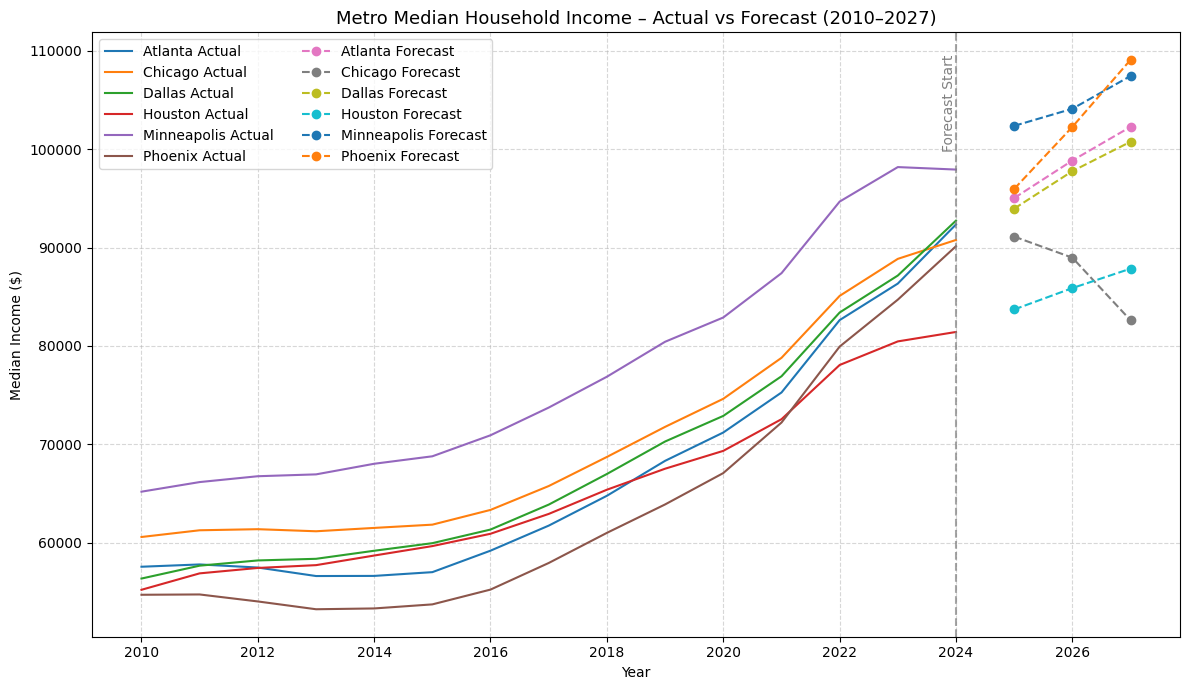

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

# Plot actual data for all metros
for metro in Combined_Income.columns:
    if metro == 'US':
        continue
    plt.plot(Combined_Income.index, Combined_Income[metro], label=f"{metro} Actual", linestyle='-')

# Plot forecasts
for metro in forecast_df.columns:
    plt.plot(forecast_df.index, forecast_df[metro], linestyle='--', marker='o', label=f"{metro} Forecast")

# Mark split line (end of actual data)
plt.axvline(x=Combined_Income.index[-1], color='gray', linestyle='--', alpha=0.7)
plt.text(Combined_Income.index[-1], plt.ylim()[1]*0.98, 'Forecast Start', rotation=90, va='top', ha='right', color='gray')

plt.title("Metro Median Household Income – Actual vs Forecast (2010–2027)", fontsize=13)
plt.xlabel("Year")
plt.ylabel("Median Income ($)")
plt.legend(loc='upper left', ncol=2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()